In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Funciones

In [38]:
def compute_all_relative_regret(
    df: pd.DataFrame,
    df_random: pd.DataFrame,
    df_full: pd.DataFrame,
    baseline_method: str = "Full-data",
    random_method: str = "random",
    metric_col: str = "test_balanced"
) -> pd.DataFrame:
    """
    Dado un df con columnas [method, model, IPC, <metric_col>], calcula
    el regret relativo para TODOS los métodos (incluido random), usando:
    
      AF = metric de baseline_method (Full-data), por model
      AR = metric de random_method, por (model, IPC)
      A  = metric de cada método, por (model, IPC)
    
    Retorna un df con columnas:
      [method, model, IPC, A, AR, AF, regret, (opcional) regret_clipped]
    """

    mean_metric_col = f'mean_{metric_col}'
    df_mean = (
        df.groupby(['method','model','IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col})
    )
    df_mean_random = (
        df_random.groupby(['method','model','IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col})
    )

    # 1) Extrae AF (una fila por model)
    df_AF = (
        df_full
        .set_index('model')[metric_col]
        .rename('AF')
        .to_frame()
    )

    df_AR = (
        df_mean_random[
            (df_mean_random['method'] == random_method) &
            (df_mean_random['IPC'] == 10)
        ]
        .set_index('model')[mean_metric_col]
        .rename('AR')
        .to_frame()
    )

    # 3) Extrae A (todos los métodos salvo full-data) por model+IPC+method
    df_A = (
        df_mean[df_mean['method'] != baseline_method]
        .set_index(['method','model','IPC'])[mean_metric_col]
        .rename('A')
        .to_frame()
        .reset_index()
    )

    #display(df_AF)
    #display(df_AR)

    df_join_AF_AR = df_AF.join(df_AR, how='inner')
    df_join_AF_AR['AF_minus_AR'] = df_join_AF_AR['AF'] - df_join_AF_AR['AR']

    #display(df_join_AF_AR)

    # 5) Cálculo de regret
    def _compute(r):
        raw_compared = df_join_AF_AR.loc[r['model']]
        denom = raw_compared['AF_minus_AR']
        
        if denom == 0 or pd.isna(denom):
            return np.nan
        if denom < 0:
            print("Denominador menor que cero")
        return (raw_compared['AF'] - r['A']) / denom

    df_A['regret'] = df_A.apply(_compute, axis=1)

    return df_A, df_mean, df_join_AF_AR

In [18]:
def plot_regret_grid(
    rr_original,
    rr_lat,
    rr_lat_ft,
    rr_random,
    models: list[str],
    methods: list[str],
    ipc_values: list[float],
    colors: dict[str,str] = None
):
    """
    Dibuja una grilla [n_modelos x n_métodos] de curvas de regret vs IPC.

    Parámetros
    ----------
    rr_original : DataFrame
        relative regret para cada (model, IPC, method) en espacio original.
    rr_lat : DataFrame
        idem, en espacio latente.
    rr_lat_ft : DataFrame
        idem, latente + fine-tuning.
    rr_random : DataFrame
        baseline random: debe contener columnas ['model','IPC','regret'].
    models : lista de modelos (strings coincidiendo con .model en los dfs).
    methods: lista de métodos de destilación (strings coincidiendo con .method).
    ipc_values: lista de valores de IPC a plotear (para ordenar el eje X).
    colors : dict opcional { método: color_hex } para cada método.
    """
    # Colores por método (fallback si no se pasa)
    default_colors = {
        'k-means':'#1f77b4', 
        'ag':'#d62728', 
        'gm':'#9467bd', 
        'kip':'#2ca02c'
    }
    colors = colors or default_colors

    n_models = len(models)
    n_methods = len(methods)
    fig, axes = plt.subplots(
        n_models, n_methods,
        #figsize=(n_methods*4, n_models*3),
        figsize=(12,8),
        sharex=True, sharey=True
    )
    if n_models==1: axes = axes[None, :]
    if n_methods==1: axes = axes[:, None]

    for i, model in enumerate(models):
        for j, method in enumerate(methods):
            ax = axes[i][j]
            c = colors.get(method, 'gray')
            # 1) Random baseline (negro, sólido)
            df_rnd = rr_random[
                (rr_random['model']==model)
            ]
            ax.plot(
                df_rnd['IPC'], df_rnd['regret'],
                '-', color='black', lw=1.5, label='RND'
            )
            # 2) Original-space
            df_o = rr_original[
                (rr_original['model']==model)&
                (rr_original['method']==method)
            ]
            ax.plot(
                df_o['IPC'], df_o['regret'],
                '-', color='blue', lw=1.5, label=f'{method} Orig.'
            )
            # 3) Latent-space
            df_l = rr_lat[
                (rr_lat['model']==model)&
                (rr_lat['method']==method)
            ]
            ax.plot(
                df_l['IPC'], df_l['regret'],
                '--', color='orange', lw=1.5, label=f'{method} Lat.'
            )
            # 4) Latent+FT
            df_f = rr_lat_ft[
                (rr_lat_ft['model']==model)&
                (rr_lat_ft['method']==method)
            ]
            ax.plot(
                df_f['IPC'], df_f['regret'],
                '-.', color='g', lw=1.5, label=f'{method} Lat FT'
            )

            ax.set_title(f"{model.upper()} - {method.upper()}")
            if i == n_models-1:
                ax.set_xlabel("Instances Per Class")
            if j == 0:
                ax.set_ylabel("Relative Regret")
            ax.set_xlim(min(ipc_values), max(ipc_values))
            ax.set_ylim(0,2)
            ax.grid(True, alpha=0.2)
            if i==0 and j==0:
                ax.legend(loc='upper right', fontsize='small')

    plt.tight_layout()
    plt.show()

# Analisis de datos aleatorios con 20 seeds para ver varianza

In [79]:
df_metrics_random = pd.read_csv('pruebas_con_random/metrics_random.csv')


In [ ]:
metric_col = 'test_balanced'
metric_col = 'test_roc_auc'
method = 'k-means'
model = 'xgb'
space = 'original'
df_metrics_random.loc[(df_metrics_random.model ==model)].groupby(['IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col+'rand'})

# Analisis de shoppers

In [66]:
df_metrics_original = pd.read_csv('checkpoint_shoppers_Doriginal_Roriginal_B/metrics.csv')
df_metrics_original = pd.read_csv('Experiments_A/checkpoint_shoppers_Doriginal_Roriginal_A/metrics.csv')
df_metrics_lat = pd.read_csv('checkpoint_shoppers_Dlatent_Roriginal_B/metrics.csv')
df_metrics_lat_ft = pd.read_csv('checkpoint_shoppers_Dlatent_Roriginal_ft_B/metrics.csv')

In [ ]:
df_metrics_lat.columns

Index(['model', 'method', 'cv_balanced', 'cv_macro_f1', 'cv_weighted_f1',
       'cv_accuracy', 'cv_balanced_std', 'cv_macro_f1_std',
       'cv_weighted_f1_std', 'cv_accuracy_std', 'optuna_time', 'train_time',
       'test_balanced', 'test_macro_f1', 'test_weighted_f1', 'test_accuracy',
       'test_roc_auc', 'inf_time_per_sample', 'space', 'IPC', 'seed',
       'vae_pretrain_time', 'vae_fine_tunning_time', 'encoder_inference_time',
       'decoder_inference_time'],
      dtype='object')

In [56]:
df_metrics_lat.space.unique()

array(['original', 'latent'], dtype=object)

In [42]:
df_metrics_original[['test_balanced','test_roc_auc']].loc[df_metrics_original.method=='Full-data'].head(), df_metrics_lat[['test_balanced','test_roc_auc']].loc[df_metrics_lat.method=='Full-data'].head(), df_metrics_lat_ft[['test_balanced','test_roc_auc']].loc[df_metrics_lat_ft.method=='Full-data'].head()

(   test_balanced  test_roc_auc
 0          0.769         0.930
 1          0.854         0.921
 2          0.771         0.884
 3          0.702         0.902
 4          0.783         0.913,
    test_balanced  test_roc_auc
 0          0.769         0.930
 1          0.857         0.922
 2          0.771         0.884
 3          0.702         0.902
 4          0.758         0.912,
    test_balanced  test_roc_auc
 0          0.769         0.930
 1          0.860         0.919
 2          0.771         0.885
 3          0.702         0.902
 4          0.777         0.917)

In [48]:
df_metrics_original = pd.read_csv('checkpoint_shoppers_Doriginal_Roriginal_B/metrics.csv')

In [68]:
r1 = df_metrics_original[['test_balanced', 'test_macro_f1', 'test_weighted_f1', 'test_accuracy','test_roc_auc']].loc[(df_metrics_original.method=='random')
                        & (df_metrics_original.model=='xgb') & (df_metrics_original.IPC==10)]
r1

,test_balanced,test_macro_f1,test_weighted_f1,test_accuracy,test_roc_auc
5,0.830,0.793,0.885,0.878,0.883
35,0.802,0.803,0.897,0.897,0.849
65,0.833,0.789,0.881,0.873,0.850
95,0.730,0.582,0.690,0.641,0.807
125,0.655,0.610,0.764,0.738,0.751


In [49]:
r2 = df_metrics_original[['test_accuracy','test_roc_auc']].loc[(df_metrics_original.method=='random')
                        & (df_metrics_original.model=='xgb') & (df_metrics_original.IPC==10)]

In [52]:
total = r1['test_roc_auc'].to_list()+r2['test_roc_auc'].to_list()
np.mean(total)

np.float64(0.8339000000000001)

In [78]:
# Graficando roc_auc

metric_col = 'test_balanced'
metric_col = 'test_roc_auc'
method = 'k-means'
model = 'xgb'
space = 'original'

#metric_col = 'test_roc_auc'
mean_metric_col = f'mean_{metric_col}'
df_fil_original = df_metrics_original.loc[(df_metrics_original.method==method) & (df_metrics_original.model ==model)].groupby(['IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col})
df_fil_lat = df_metrics_lat.loc[(df_metrics_lat.method==method) & (df_metrics_lat.model ==model) & (df_metrics_lat.space ==space)].groupby(['IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col+'lat'})
df_fil_lat_ft = df_metrics_lat_ft.loc[(df_metrics_lat_ft.method==method) & (df_metrics_lat_ft.model ==model)& (df_metrics_lat.space ==space)].groupby(['IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col+'lat_ft'})
df_fil_random_ft = df_metrics_lat_ft.loc[(df_metrics_lat_ft.method=='random') & (df_metrics_lat_ft.model ==model)].groupby(['IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col+'rand'})

df1 = df_fil_original.set_index('IPC')
df2 = df_fil_lat.set_index('IPC')
df3 = df_fil_lat_ft.set_index('IPC')
df4 = df_fil_random_ft.set_index('IPC')

# 2) Concatenar horizontalmente (axis=1)
df_concat = pd.concat([df1, df2, df3,df4], axis=1)

# 3) (Opcional) devolver 'IPC' como columna
df_concat = df_concat.reset_index()
df_concat

,IPC,mean_test_roc_auc,mean_test_roc_auclat,mean_test_roc_auclat_ft,mean_test_roc_aucrand
0,10.0,0.8548,0.8326,0.8332,0.8398
1,20.0,0.8756,0.8738,0.8884,0.8584
2,30.0,0.8788,0.8750,0.8814,0.8768
3,40.0,0.8652,0.8806,0.8790,0.8742
4,50.0,0.8736,0.8882,0.8754,0.8944
5,60.0,0.8770,0.8832,0.8788,0.8968
6,70.0,0.8686,0.8796,0.8808,0.8954
7,80.0,0.8526,0.8822,0.8688,0.8976
8,90.0,0.8676,0.8908,0.8778,0.8896
9,100.0,0.8724,0.8864,0.8638,0.8890


In [63]:
df_metrics_lat.loc[(df_metrics_lat.method==method) & (df_metrics_lat.model ==model)].space.unique()

array(['original'], dtype=object)

In [93]:
df_metrics_original = pd.read_csv('checkpoint_shoppers_Doriginal_Roriginal/metrics.csv')
df_metrics_lat = pd.read_csv('checkpoint_shoppers_Dlatent_Roriginal/metrics.csv')
df_metrics_lat_ft = pd.read_csv('checkpoint_shoppers_Dlatent_Roriginal_ft/metrics.csv')

# Graficando roc_auc

metric_col = 'test_balanced'
metric_col = 'test_roc_auc'
#metric_col = 'test_weighted_f1'
method = 'k-means'
model = 'xgb'

#metric_col = 'test_roc_auc'
mean_metric_col = f'mean_{metric_col}'
df_fil_original = df_metrics_original.loc[(df_metrics_original.method==method) & (df_metrics_original.model ==model)].groupby(['IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col})
df_fil_lat = df_metrics_lat.loc[(df_metrics_lat.method==method) & (df_metrics_lat.model ==model)].groupby(['IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col+'lat'})
df_fil_lat_ft = df_metrics_lat_ft.loc[(df_metrics_lat_ft.method==method) & (df_metrics_lat_ft.model ==model)].groupby(['IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col+'lat_ft'})
df_fil_random_ft = df_metrics_lat_ft.loc[(df_metrics_lat_ft.method=='random') & (df_metrics_lat_ft.model ==model)].groupby(['IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col+'rand'})

df1 = df_fil_original.set_index('IPC')
df2 = df_fil_lat.set_index('IPC')
df3 = df_fil_lat_ft.set_index('IPC')
df4 = df_fil_random_ft.set_index('IPC')

# 2) Concatenar horizontalmente (axis=1)
df_concat = pd.concat([df1, df2, df3,df4], axis=1)

# 3) (Opcional) devolver 'IPC' como columna
df_concat = df_concat.reset_index()
df_concat

,IPC,mean_test_roc_auc,mean_test_roc_auclat,mean_test_roc_auclat_ft,mean_test_roc_aucrand
0,10,0.8642,0.8656,0.8245,0.84725
1,20,0.8756,NaN,NaN,NaN


In [36]:
df_metrics_lat.columns

Index(['model', 'method', 'cv_balanced', 'cv_macro_f1', 'cv_weighted_f1',
       'cv_accuracy', 'cv_balanced_std', 'cv_macro_f1_std',
       'cv_weighted_f1_std', 'cv_accuracy_std', 'optuna_time', 'train_time',
       'test_balanced', 'test_macro_f1', 'test_weighted_f1', 'test_accuracy',
       'test_roc_auc', 'inf_time_per_sample', 'IPC', 'seed',
       'vae_pretrain_time', 'vae_fine_tunning_time', 'encoder_inference_time',
       'decoder_inference_time'],
      dtype='object')

In [73]:
df_metrics_lat.method.unique()

array(['Full-data', 'random', 'k-means', 'ag', 'k_center', 'craig', 'lc'],
      dtype=object)

In [37]:
df_metrics_original[['model','test_balanced','test_roc_auc','IPC']][(df_metrics_original['IPC'].isin([90,np.nan])) & (df_metrics_original['model'] == 'xgb')]

,model,test_balanced,test_roc_auc,IPC
0,xgb,0.769,0.930,NaN
1205,xgb,0.835,0.900,90.0
1210,xgb,0.512,0.862,90.0
1215,xgb,0.825,0.897,90.0
1220,xgb,0.805,0.867,90.0
1225,xgb,0.769,0.807,90.0
1230,xgb,0.331,0.165,90.0
1235,xgb,0.831,0.893,90.0
1240,xgb,0.498,0.878,90.0
1245,xgb,0.718,0.882,90.0


Calculo de test roc auc

In [39]:
metric = 'test_roc_auc'
metric = 'test_balanced'

df_random = df_metrics_lat[df_metrics_lat.method == 'random']
df_real = df_metrics_lat[df_metrics_lat.method == 'Full-data']

rr_original,_, df_join_AF_AR = compute_all_relative_regret(df_metrics_original, df_random, df_real, metric_col=metric)
rr_lat,_,_ = compute_all_relative_regret(df_metrics_lat,df_random, df_real, metric_col=metric)
rr_lat_ft,_,_ = compute_all_relative_regret(df_metrics_lat_ft,df_random, df_real, metric_col=metric)
rr_random = rr_lat.loc[rr_lat.method == 'random']

Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
D

In [40]:
df_join_AF_AR

,AF,AR,AF_minus_AR
model,,,
xgb,0.769,0.7824,-0.0134
rf,0.857,0.7384,0.1186
svc,0.771,0.7038,0.0672
logreg,0.702,0.7582,-0.0562
mlp,0.758,0.7110,0.0470


In [40]:
rr_random.shape, rr_original.shape

((65, 5), (390, 5))

In [41]:
rr_random.head()

,method,model,IPC,A,regret
325,random,logreg,10.0,0.8278,1.000000
326,random,logreg,20.0,0.8386,0.854447
327,random,logreg,30.0,0.8592,0.576819
328,random,logreg,40.0,0.8604,0.560647
329,random,logreg,50.0,0.8650,0.498652


In [42]:
rr_original.head()

,method,model,IPC,A,regret
0,ag,logreg,10.0,0.8610,0.552561
1,ag,logreg,20.0,0.7198,2.455526
2,ag,logreg,30.0,0.6796,2.997305
3,ag,logreg,40.0,0.6854,2.919137
4,ag,logreg,50.0,0.6866,2.902965


In [43]:
rr_original.method.unique()

array(['ag', 'craig', 'k-means', 'k_center', 'lc', 'random'], dtype=object)

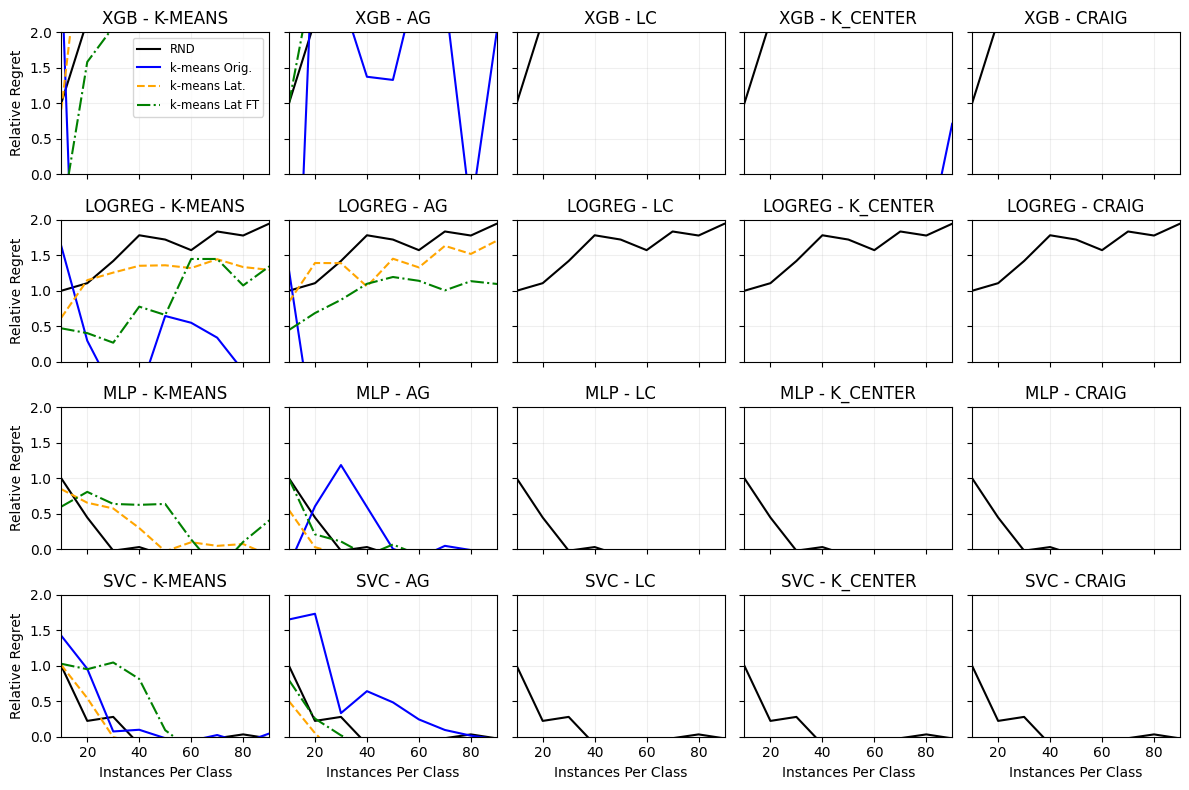

In [29]:
models = ['xgb','logreg','mlp','svc']
methods = ['k-means','ag','lc','k_center','craig']
ipc_values = sorted(rr_original['IPC'].unique())[:9]

plot_regret_grid(
    rr_original=rr_original,
    rr_lat=rr_lat,
    rr_lat_ft=rr_lat_ft,
    rr_random = rr_random,
    models=models,
    methods=methods,
    ipc_values=ipc_values
)

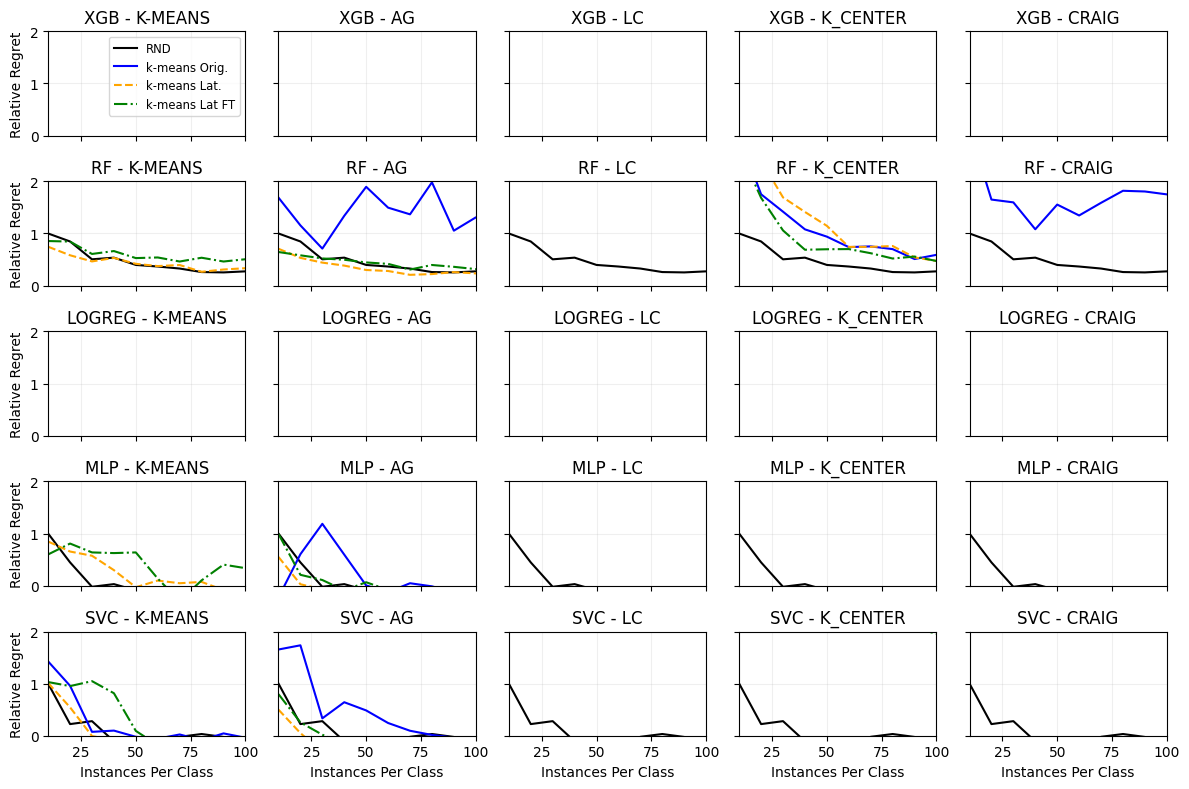

In [37]:
models = ['xgb','rf','logreg','mlp','svc']
methods = ['k-means','ag','lc','k_center','craig']
ipc_values = sorted(rr_lat['IPC'].unique())[:10]

plot_regret_grid(
    rr_original=rr_original,
    rr_lat=rr_lat,
    rr_lat_ft=rr_lat_ft,
    rr_random = rr_random,
    models=models,
    methods=methods,
    ipc_values=ipc_values
)

# Otras cosas

In [17]:
df_metrics_original[['model','method','IPC','seed','test_balanced']].head(5)

,model,method,IPC,seed,test_balanced
0,xgb,Full-data,NaN,NaN,0.769
1,rf,Full-data,NaN,NaN,0.854
2,svc,Full-data,NaN,NaN,0.771
3,logreg,Full-data,NaN,NaN,0.702
4,mlp,Full-data,NaN,NaN,0.783


In [10]:
df_metrics_lat.head()

,model,method,cv_balanced,cv_macro_f1,cv_weighted_f1,cv_accuracy,cv_balanced_std,cv_macro_f1_std,cv_weighted_f1_std,cv_accuracy_std,...,test_weighted_f1,test_accuracy,test_roc_auc,inf_time_per_sample,IPC,seed,vae_pretrain_time,vae_fine_tunning_time,encoder_inference_time,decoder_inference_time
0,xgb,Full-data,0.778,0.798,0.898,0.902,0.008,0.007,0.003,0.003,...,0.898,0.903,0.930,0.000017,NaN,NaN,NaN,NaN,NaN,NaN
1,rf,Full-data,0.853,0.787,0.877,0.866,0.010,0.007,0.005,0.006,...,0.882,0.872,0.921,0.000043,NaN,NaN,NaN,NaN,NaN,NaN
2,svc,Full-data,0.744,0.770,0.885,0.892,0.005,0.006,0.003,0.003,...,0.897,0.902,0.885,0.000259,NaN,NaN,NaN,NaN,NaN,NaN
3,logreg,Full-data,0.677,0.717,0.866,0.882,0.006,0.005,0.002,0.002,...,0.880,0.894,0.902,0.000001,NaN,NaN,NaN,NaN,NaN,NaN
4,mlp,Full-data,0.757,0.778,0.889,0.893,0.006,0.007,0.004,0.004,...,0.881,0.884,0.911,0.000041,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df_metrics_lat_ft.head()

,model,method,cv_balanced,cv_macro_f1,cv_weighted_f1,cv_accuracy,cv_balanced_std,cv_macro_f1_std,cv_weighted_f1_std,cv_accuracy_std,...,test_weighted_f1,test_accuracy,test_roc_auc,inf_time_per_sample,IPC,seed,vae_pretrain_time,vae_fine_tunning_time,encoder_inference_time,decoder_inference_time
0,xgb,Full-data,0.778,0.798,0.898,0.902,0.008,0.007,0.003,0.003,...,0.898,0.903,0.930,0.000013,NaN,NaN,NaN,NaN,NaN,NaN
1,rf,Full-data,0.850,0.786,0.876,0.865,0.009,0.008,0.005,0.007,...,0.878,0.867,0.921,0.000023,NaN,NaN,NaN,NaN,NaN,NaN
2,svc,Full-data,0.744,0.770,0.885,0.892,0.005,0.006,0.003,0.003,...,0.897,0.902,0.885,0.000258,NaN,NaN,NaN,NaN,NaN,NaN
3,logreg,Full-data,0.677,0.717,0.866,0.882,0.006,0.005,0.002,0.002,...,0.880,0.894,0.902,0.000001,NaN,NaN,NaN,NaN,NaN,NaN
4,mlp,Full-data,0.767,0.787,0.893,0.897,0.010,0.009,0.004,0.004,...,0.893,0.896,0.924,0.000011,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df_rr_original = pd.read_csv('checkpoint_shoppers_Doriginal_Roriginal_A/relative_regret.csv')
df_rr_lat = pd.read_csv('checkpoint_shoppers_Dlatent_Roriginal_A/relative_regret.csv')
df_rr_lat_tf = pd.read_csv('checkpoint_shoppers_Dlatent_Roriginal_ft_A/relative_regret.csv')

In [6]:
df_rr_lat.head()

,method,ipc,model,regret_mean,regret_std
0,k-means,10,xgb,-0.277472,0.597593
1,k-means,10,rf,1.258424,0.445051
2,k-means,10,svc,3.467534,6.828530
3,k-means,10,logreg,0.099832,2.501407
4,k-means,10,mlp,0.093178,0.884185


In [ ]:
compute_relative_regret